In [51]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import SystemMessage, AIMessage

load_dotenv(override=True)
checkpointer = InMemorySaver()

In [34]:
openai_key = os.getenv("OPENAI_API_KEY")

llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=openai_key,
    temperature=0.2,
    max_tokens=None,
    max_retries=2
)
llm2 = ChatOpenAI(
    model="gpt-4.1-nano",
    api_key=openai_key,
    temperature=0.2,
    max_tokens=None,
    max_retries=2
)

In [ ]:
topics = [{
    "topic": "Small Business Defined",
    "notes": f"""Small businesses are often the starting point for entrepreneurs as they develop their ideas and build a customer base. 
    The Small Business Administration (SBA) defines a small business as a for-profit entity with fewer than 500 employees. This definition makes
    these businesses eligible for various government programs and preferences. Small businesses play a crucial role in our economy and communities."""
    },
    {
    "topic": "Small Business Impact",
    "notes": f"""There are over 33.2 million small businesses in the United States, making up 99.9% of all firms. From 1995 to 2021, small businesses created 
    17.3 million net new jobs, significantly more than large businesses. Despite challenges like the COVID-19 recession, small businesses rebounded quickly,
    demonstrating their resilience and importance to economic recovery. They contribute to local economies by reinvesting paychecks and taxes, supporting 
    new businesses, and improving
    public services. On average, small businesses offer competitive wages, averaging $30.42 per hour, translating to an annual income of $63,000."""
    },
    {
    "topic": "Small Business Demographics",
    "notes": f"""43.4% of small businesses are owned by females, reflecting progress toward gender equality in entrepreneurship.
    20.4% are owned by racial minorities, including 14.5% by Hispanics.
    6.1% are owned by veterans, contributing diverse perspectives to the U.S. economy.
    Hispanic-owned businesses, for example, pay over $100 billion annually in payroll to their 1 million workers."""
    }
    ]

In [70]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, MessagesState

class TopicState(MessagesState):
    title: str
    notes: str
    question: str
    reply: str
    hint_taken: bool
    

In [ ]:
class AnswerState(MessagesState):
    index: int
    max_ind: int
    topic: TopicState
    topics: list
    

In [ ]:
dialogues: AnswerState = {
    "index": -1,    
    "topics": [],
    "topic": {
    },
    max_index: 0
}

In [145]:
def initialize_graph(state: DialogueState) -> DialogueState:
    state["topics"] = topics
    state["max_ind"] = len(topics)
    state["index"] = -1
    return state

In [160]:
def set_index(state: DialogueState) -> DialogueState:
    state["index"] += 1
    return state

In [147]:
from typing import Literal

def check_termination(state: DialogueState) -> Literal["continue", "terminate"]:
    return "terminate" if state["index"] >= state["max_ind"] else "continue"

In [172]:
def set_question(state: DialogueState) -> DialogueState:
    question_topic = state["topics"][state["index"]]
    topic, notes, hint_taken = question_topic["topic"], question_topic["notes"], False

    question_prompt = f"""
    You are an examiner whose job is to prepare a conceptual question (subjective) on a topic using the notes provided to you.
    Topic: {topic}
    Notes: {notes}
    Keep the question simple, just to test a basic understanding. Do not provide the answer.
    """
    question = llm.invoke(question_prompt).content
    
    state["topic"] = {
        "topic": topic,
        "notes": notes,
        "question": question,
        "hint_taken": hint_taken,
        "reply": "",
        "messages": []
    }
    return state
    

In [165]:
def get_student_answer(state: DialogueState):
    user_answer = input(state["topic"]["question"])
    state["topic"]["reply"] = user_answer
    return state
    

In [150]:
from pydantic import BaseModel

class EvalSchema(BaseModel):
    evaluation: Literal["satisfactory", "unsatisfactory", "hint"]
    comment: str

In [151]:
def evaluate(state: DialogueState) -> Literal["hint", "satisfactory", "unsatisfactory"]:  
    """
    Evaluate the user reply, using LLM.
    Returns correct, retry or limits reached outputs
    """
    if not state["topic"]["hint_taken"]:
        ai_prompt = f"""
            You have to analyze the user's reply to a question to check the understanding of a concept and tell whether
            it is acceptable using notes provided to you. 
            Return: satisfactory or unsatisfactory, along with some comment on the users answer. 
            If not satisfactory, give hint in the comment
            without giving complete answer.
            Keep user as the first person and address the answer to user only.
            Question: {state["topic"]["question"]}
            Notes: {state["topic"]["notes"]}
            User's reply: {state["topic"]["reply"]}
        """
    else:
        ai_prompt = f"""
            You have to analyze the user's reply to a question to check the understanding of a concept and tell whether
            it is acceptable using notes provided to you. 
            Return: satisfactory or unsatisfactory, along with some comment on the users answer. 
            If not satisfactory, give answer using notes.
            Keep user as the first person and address the answer to user only.
            
            Question: {state["topic"]["question"]}
            Notes: {state["topic"]["notes"]}
            User's reply: {state["topic"]["reply"]}
        """
    
    llm_s = llm.with_structured_output(EvalSchema)
    evaluation = llm_s.invoke(ai_prompt)
    state["topic"]["messages"].append(AIMessage(content=evaluation.comment))
    
    if evaluation.evaluation == "satisfactory":        
        return "satisfactory"
    else:
        if not state["topic"]["hint_taken"]:            
            return "hint"
        else:
            return "unsatisfactory"
    
    

In [152]:
def satisfactory(state):
    user_input = input(state["topic"]["messages"][-1].content)
    return state

In [153]:
def hint(state):
    print(state["topic"]["messages"][-1].content)
    state["topic"]["hint_taken"] = True
    return state

In [154]:
def unsatisfactory(state):
    user_input = input(state["topic"]["messages"][-1].content)
    return state

In [ ]:
from langgraph.graph import StateGraph, END

builder = StateGraph(AnswerState)

builder.add_node("initialize_graph", initialize_graph)
builder.add_node("set_index", set_index)
builder.add_node("set_question", set_question)
builder.add_node("get_student_answer", get_student_answer)
builder.add_node("satisfactory", satisfactory)
builder.add_node("hint", hint)
builder.add_node("unsatisfactory", unsatisfactory)

builder.set_entry_point("initialize_graph")

builder.add_conditional_edges(
    "set_index",
    check_termination,
    {
        "terminate": END,
        "continue": "set_question",
    }
)
builder.add_conditional_edges(
    "get_student_answer", 
    evaluate,
    {
         "satisfactory": "satisfactory",
         "unsatisfactory": "unsatisfactory",
         "hint": "hint"
    }
)
builder.add_edge("initialize_graph", "set_index")
builder.add_edge("set_question", "get_student_answer")
builder.add_edge("satisfactory", "set_index")
builder.add_edge("unsatisfactory", "set_index")
builder.add_edge("hint", "get_student_answer")




In [168]:
graph = builder.compile()

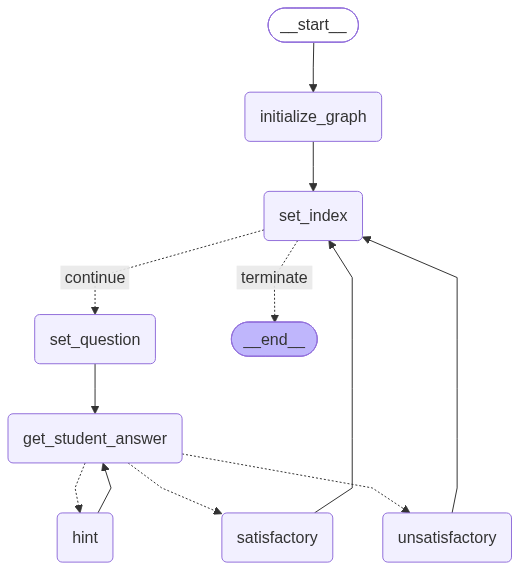

In [169]:
graph

In [170]:
s = {
    "topics": topics,
    "topic": {
    }
}


In [171]:
graph.invoke(s)

What is the definition of a small business according to the Small Business Administration (SBA), and why are small businesses important to the economy and communities? Small businesses are often the starting point for entrepreneurs as they develop their ideas and build a customer base.      The Small Business Administration (SBA) defines a small business as a for-profit entity with fewer than 500 employees. This definition makes     these businesses eligible for various government programs and preferences. Small businesses play a crucial role in our economy and communities.
Your answer accurately reflects the definition of a small business according to the SBA and highlights their importance to the economy and communities. Great job! thanks
Question: What percentage of all firms in the United States are classified as small businesses, and how many net new jobs did they create from 1995 to 2021? Not sure, give a hint


It seems you are unsure about the answer. Remember, small businesses make up a significant percentage of all firms in the U.S. and have created millions of jobs over a specific period. Try to recall the exact figures for both the percentage and the number of jobs.


Question: What percentage of all firms in the United States are classified as small businesses, and how many net new jobs did they create from 1995 to 2021? There are over 33.2 million small businesses in the United States, making up 99.9% of all firms. From 1995 to 2021, small businesses created      17.3 million net new jobs, significantly more than large businesses. Despite challenges like the COVID-19 recession, small businesses rebounded quickly,     demonstrating their resilience and importance to economic recovery. They contribute to local economies by reinvesting paychecks and taxes, supporting      new businesses, and improving     public services. On average, small businesses offer competitive wages, averaging $30.42 per hour, translating to an annual income of $63,000.
Your answer accurately reflects the information provided in the notes. You correctly stated the percentage of small businesses and the number of net new jobs they created, along with additional context about t

Your answer of '10' does not accurately reflect the percentage of small businesses owned by females in the U.S. Remember, it's significantly higher than that. Consider revisiting the statistics to provide a more accurate figure.


What percentage of small businesses in the U.S. are owned by females, and how does this reflect progress toward gender equality in entrepreneurship? 50
Your answer of 50% is incorrect. The correct percentage of small businesses owned by females in the U.S. is 43.4%. This statistic reflects progress toward gender equality in entrepreneurship. ok


{'messages': [],
 'index': 3,
 'max_ind': 3,
 'topic': {'topic': 'Small Business Demographics',
  'notes': '43.4% of small businesses are owned by females, reflecting progress toward gender equality in entrepreneurship.\n    20.4% are owned by racial minorities, including 14.5% by Hispanics.\n    6.1% are owned by veterans, contributing diverse perspectives to the U.S. economy.\n    Hispanic-owned businesses, for example, pay over $100 billion annually in payroll to their 1 million workers.',
  'question': 'What percentage of small businesses in the U.S. are owned by females, and how does this reflect progress toward gender equality in entrepreneurship?',
  'hint_taken': True,
  'reply': '50',
  'messages': [AIMessage(content="Your answer of '10' does not accurately reflect the percentage of small businesses owned by females in the U.S. Remember, it's significantly higher than that. Consider revisiting the statistics to provide a more accurate figure.", additional_kwargs={}, response_m

In [119]:
x = [1]
x.append(2)
x

[1, 2]